# Regional damage

In this tutorial, you will learn about how Lacuna can help you measure regional lesion load using the command line interface.

**What you'll learn:**

- Run a regional damage analysis on a BIDS dataset
- Interpret parcel-level damage outputs
- Visualize lesion–atlas overlap
- Collect individual outputs into a group-level table

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/regional-damage.ipynb)


## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install yabplot and pyvista for visualization
!pip install yabplot pyvista==0.47.1

Get the tutorial data.

In [2]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids

The tutorial dataset includes:
  - 3 synthetic subjects (sub-01, sub-02, sub-03)
  - Binary lesion masks in MNI152NLin6Asym space
  - BIDS-style structure


## Analysis

For the regional damage analysis Lacuna simply measures the overlap of a lesion with an atlas.

Run the analysis on all tutorial data.

In [12]:
!lacuna run rd \
    /tmp/tutorial_bids/ \
    /tmp/outputs_rd/ \
    --parcel-atlases schaefer2018parcels100networks7 \
    --mask-space MNI152NLin6Asym

In [13]:
!ls /tmp/outputs_rd/

dataset_description.json  sub-01  sub-02  sub-03


Load an exemplary output.

In [14]:
!ls /tmp/outputs_rd/sub-01/ses-01/anat/

sub-01_ses-01_desc-provenance.json
sub-01_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagebin_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagebin_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagepct_parcelstats.json
sub-01_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagepct_parcelstats.tsv
sub-01_ses-01_label-acuteinfarct_space-MNI152NLin6Asym_mask.nii.gz


In [15]:
import pandas as pd

output_tsv = "/tmp/outputs_rd/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagepct_parcelstats.tsv"
df = pd.read_csv(output_tsv, sep="\t")
df.sort_values(by="value", ascending=False).head(10)

,region,value
54,7Networks_RH_Vis_5,63.361935
55,7Networks_RH_Vis_6,28.837823
98,7Networks_RH_Default_pCunPCC_1,15.208071
5,7Networks_LH_Vis_6,11.231361
57,7Networks_RH_Vis_8,4.003756
8,7Networks_LH_Vis_9,1.594878
99,7Networks_RH_Default_pCunPCC_2,0.892061
48,7Networks_LH_Default_pCunPCC_1,0.739910
88,7Networks_RH_Cont_pCun_1,0.652838
2,7Networks_LH_Vis_3,0.577883


Schaefer area RH Vis 5 has the highest overlap with the lesion. Check the overlap of lesion (red) and atlas parcel (blue) visually.  

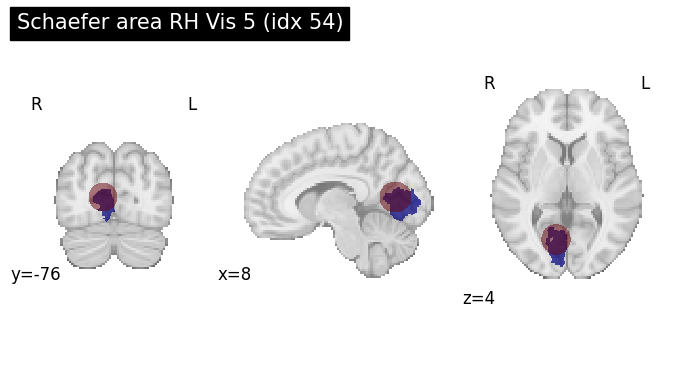

In [16]:
from lacuna.assets.parcellations import load_parcellation
import nibabel as nib
from nilearn import plotting

schaefer = load_parcellation("schaefer2018parcels100networks7")
schaefer_data = schaefer.image.get_fdata()
schaefer_roi_54 = (schaefer_data == 55)
roi_img = nib.Nifti1Image(schaefer_roi_54, affine=schaefer.image.affine, header=schaefer.image.header)

lesion_img = nib.load("/tmp/tutorial_bids/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz")

plot = plotting.plot_roi(roi_img, 
                       radiological=True, 
                       title="Schaefer area RH Vis 5 (idx 54)", 
                       draw_cross=False, 
                       colorbar=False)

plot.add_overlay(
    lesion_img, 
    cmap='Reds_r',
    transparency=0.5
)

Next, gather all individual-level outputs into a single analysis-ready table with `lacuna collect`

In [ ]:
!lacuna collect \
    /tmp/outputs_rd/ \
    --pattern "*schaefer2018*" \
    --output-dir /tmp/group_outputs/ \
    --verbose

2026-04-01 09:36:44 - lacuna.cli.main - INFO - Running collect (group-level aggregation)
2026-04-01 09:36:44 - lacuna.cli.main - INFO - Scanning derivatives directory: /tmp/outputs_rd
2026-04-01 09:36:44 - lacuna.cli.main - INFO - Output directory: /tmp/group_outputs
2026-04-01 09:36:44 - lacuna.cli.main - INFO - Pattern: *schaefer2018*_parcelstats.tsv
2026-04-01 09:36:44 - lacuna.cli.main - INFO - Found 6 file(s) across 3 subject(s) and 2 output type(s)
  Reading ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networ
                                                                                
  Reading ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networ
2026-04-01 09:36:44 - lacuna.cli.main - INFO - Created 2 group-level TSV file(s):
2026-04-01 09:36:44 - lacuna.cli.main - INFO -   - group_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagepct_parcelstats.tsv
2026-04-01 09:36:44 - lacuna.cli.main - INFO -   - gro

In [19]:
parcel_df = pd.read_csv("/tmp/group_outputs/group_ses-01_label-acuteinfarct_method-rd_atlas-schaefer2018parcels100networks7_desc-damagepct_parcelstats.tsv", sep="\t", index_col=0)
parcel_df

,session_id,label,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,...,7Networks_RH_Default_Temp_1,7Networks_RH_Default_Temp_2,7Networks_RH_Default_Temp_3,7Networks_RH_Default_PFCv_1,7Networks_RH_Default_PFCv_2,7Networks_RH_Default_PFCdPFCm_1,7Networks_RH_Default_PFCdPFCm_2,7Networks_RH_Default_PFCdPFCm_3,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2
participant_id,,,,,,,,,,,,,,,,,,,,,
1,1,acuteinfarct,0.0,0.0,0.577883,0.0,0.118796,11.231361,0.0,0.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,15.208071,0.892061
2,1,acuteinfarct,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,1,acuteinfarct,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,13.600105,5.60675,29.534862,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
